In [1]:
!pip install -q transformers==4.41.2 peft==0.11.1 accelerate==0.31.0 datasets

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix
)

from sklearn.metrics.pairwise import cosine_similarity

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

from peft import AdaLoraConfig,get_peft_model

from google.colab import drive
drive.mount('/content/drive',force_remount=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.4/309.4 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 40.9 MB/s eta 0:00:00
Mounted at /content/drive


In [9]:
file_path="/content/drive/MyDrive/E-Commerce Reviews (5 Classes).csv"

df=pd.read_csv(
    file_path,
    encoding='ISO-8859-1'
)

df=df[['Text','Sentiment']].dropna()

total_instances=len(df)

print(f"Total instances:{total_instances}")

print(df['Sentiment'].value_counts())


sentiment_to_label={

    "Very Negative":0,
    "Negative":1,
    "Neutral":2,
    "Positive":3,
    "Very Positive":4
}


df['label']=df['Sentiment'].map(
    sentiment_to_label
)


print("\nNumber of instances per label:")

print(
    df['label'].value_counts().sort_index()
)


train_texts,temp_texts,train_labels,temp_labels=train_test_split(

    df['Text'].tolist(),
    df['label'].tolist(),

    test_size=0.2,

    random_state=42,

    stratify=df['label']
)


val_texts,test_texts,val_labels,test_labels=train_test_split(

    temp_texts,
    temp_labels,

    test_size=0.5,

    random_state=42,

    stratify=temp_labels
)

print(
f"\nTrain size:{len(train_texts)} | Val size:{len(val_texts)} | Test size:{len(test_texts)}"
)

Total instances:22641
Sentiment
Very Positive    12540
Positive          4908
Neutral           2823
Negative          1549
Very Negative      821
Name: count, dtype: int64

Number of instances per label:
label
0      821
1     1549
2     2823
3     4908
4    12540
Name: count, dtype: int64

Train size:18112 | Val size:2264 | Test size:2265


In [10]:
model_name="bert-base-multilingual-uncased"

tokenizer=AutoTokenizer.from_pretrained(
    model_name
)

train_enc=tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=256
)

val_enc=tokenizer(
    val_texts,
    truncation=True,
    padding=True,
    max_length=256
)

test_enc=tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=256
)


class ReviewDataset(torch.utils.data.Dataset):

    def __init__(self,encodings,labels):

        self.encodings=encodings
        self.labels=labels

    def __getitem__(self,idx):

        return {

            k:torch.tensor(v[idx])

            for k,v in self.encodings.items()

        } | {

            'labels':torch.tensor(
                self.labels[idx]
            )
        }

    def __len__(self):

        return len(self.labels)


train_ds=ReviewDataset(
    train_enc,
    train_labels
)

val_ds=ReviewDataset(
    val_enc,
    val_labels
)

test_ds=ReviewDataset(
    test_enc,
    test_labels
)

In [11]:
def compute_metrics(eval_pred):

    logits,labels=eval_pred

    preds=np.argmax(
        logits,
        axis=1
    )

    acc=accuracy_score(
        labels,
        preds
    )*100


    prec,rec,f1,_=precision_recall_fscore_support(

        labels,
        preds,
        average='macro'
    )


    return {

        "Accuracy":acc,

        "Precision":prec*100,

        "Recall":rec*100,

        "F1 Score":f1*100
    }

In [12]:
model=AutoModelForSequenceClassification.from_pretrained(

    model_name,

    num_labels=5
)


adalora_cfg=AdaLoraConfig(

    task_type="SEQ_CLS",

    init_r=12,
    target_r=8,

    beta1=0.85,
    beta2=0.85,

    tinit=200,
    tfinal=1000,
    deltaT=10,

    lora_alpha=32,

    lora_dropout=0.1,

    target_modules=[
        "query",
        "value"
    ]
)


model=get_peft_model(
    model,
    adalora_cfg
)

model.print_trainable_parameters()


args=TrainingArguments(

    output_dir="./adalora-mbert",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-4,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,

    num_train_epochs=5,

    fp16=True,

    load_best_model_at_end=True,

    metric_for_best_model="eval_loss",

    greater_is_better=False,

    report_to="none",

    save_total_limit=2
)


trainer=Trainer(

    model=model,

    args=args,

    train_dataset=train_ds,

    eval_dataset=val_ds,

    compute_metrics=compute_metrics
)

start=time.time()

train_output=trainer.train()

training_time=time.time()-start

metrics=trainer.evaluate(
    test_ds
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:477: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


trainable params: 446,501 || all params: 167,806,786 || trainable%: 0.2661


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 score
1,0.976800,1.021426,60.203180,26.570492,27.733279,25.915326
2,0.925200,0.896430,62.190813,35.552042,36.452078,32.032395
3,0.896500,0.863670,63.118375,37.131317,36.951143,34.583596
4,0.842500,0.842636,63.118375,43.761233,38.603005,37.885038
5,0.834000,0.839409,63.780919,46.618416,39.768629,39.134879


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: Futur

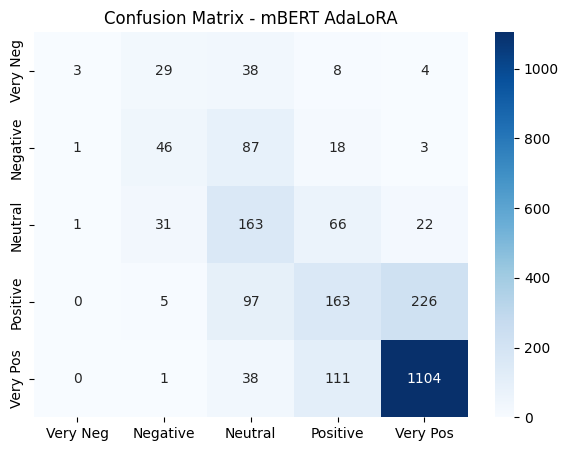

In [13]:
preds_out=trainer.predict(
    test_ds
)

preds=np.argmax(
    preds_out.predictions,
    axis=1
)

cm=confusion_matrix(
    test_ds.labels,
    preds,
    labels=[0,1,2,3,4]
)

plt.figure(figsize=(7,5))

sns.heatmap(

    cm,

    annot=True,
    fmt="d",

    cmap="Blues",

    xticklabels=[
        "Very Neg",
        "Negative",
        "Neutral",
        "Positive",
        "Very Pos"
    ],

    yticklabels=[
        "Very Neg",
        "Negative",
        "Neutral",
        "Positive",
        "Very Pos"
    ]
)

plt.title(
    "Confusion Matrix - mBERT AdaLoRA"
)

plt.show()

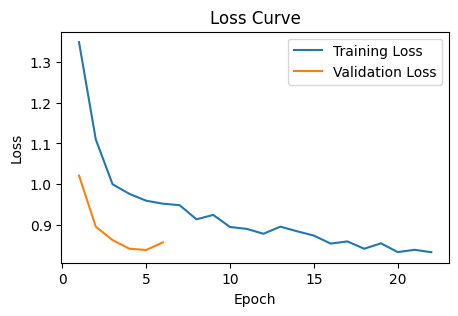

In [14]:
history=trainer.state.log_history


train_loss=[

    x["loss"]

    for x in history

    if "loss" in x
]


eval_loss=[

    x["eval_loss"]

    for x in history

    if "eval_loss" in x
]


plt.figure(figsize=(5,3))

plt.plot(
    range(1,len(train_loss)+1),
    train_loss,
    label="Training Loss"
)

plt.plot(
    range(1,len(eval_loss)+1),
    eval_loss,
    label="Validation Loss"
)

plt.title(
    "Loss Curve"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(False)

plt.show()

In [15]:
probs=torch.softmax(

    torch.tensor(
        preds_out.predictions
    ),

    dim=1
)

confidence=probs.max(
    dim=1
).values.numpy().mean()*100


labels_onehot=np.eye(
    5
)[test_ds.labels]


similarity=cosine_similarity(

    preds_out.predictions,
    labels_onehot
).mean()*100


results={

"Model":"AdaLoRA mBERT",

"Accuracy":
f"{metrics['eval_Accuracy']:.2f}%",

"Precision":
f"{metrics['eval_Precision']:.2f}%",

"Recall":
f"{metrics['eval_Recall']:.2f}%",

"F1 Score":
f"{metrics['eval_F1 Score']:.2f}%",

"Similarity":
f"{similarity:.2f}%",

"Confidence":
f"{confidence:.2f}%",

"Training Time (s)":
f"{training_time:.2f}",

"Trainable Params":
sum(
p.numel()
for p in model.parameters()
if p.requires_grad
),

"GPU Memory (GB)":
f"{torch.cuda.max_memory_allocated()/1024**3:.4f}"

}

comparison_df=pd.DataFrame(
    [results]
)

print(
comparison_df.to_string(index=False)
)

        Model Accuracy Precision Recall F1 Score Similarity Confidence Training Time (s)  Trainable Params GPU Memory (GB)
AdaLoRA mBERT   65.30%    53.08% 42.43%   42.01%      8.47%     66.05%           1032.91            446501          1.4494
